<a href="https://colab.research.google.com/github/Kigunda-lilian/Data_science/blob/main/lec6_notebook_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Practice Question 6-1

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cancer = load_breast_cancer(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, stratify=cancer.target, random_state=42)

model = LogisticRegression(max_iter=10000, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')

[[39  3]
 [ 1 71]]
Accuracy:  0.965
Precision: 0.959
Recall:    0.986
F1:        0.973


### Practice Question 6-2

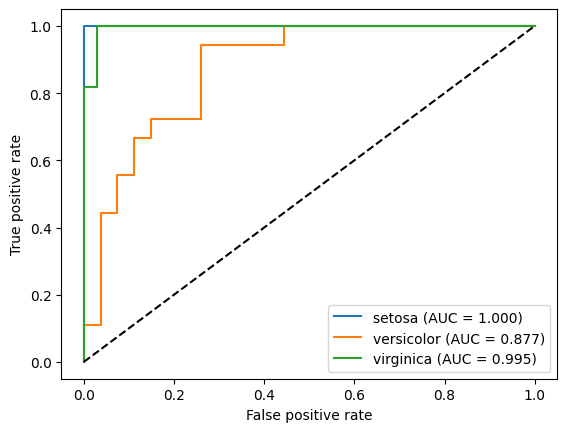

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

iris = load_iris()
y_bin = label_binarize(iris.target, classes=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, y_bin, test_size=0.3, random_state=0)

model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=0))
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

for i, name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()